In [36]:
import sys
import os
import pandas as pd 
import matplotlib.pyplot as plt

In [37]:
df_daily = pd.read_csv("/Users/dimitris/LU/Thesis/thesis-code-new/data/MSFT/MSFT_1d.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['Date'])
df_daily  = df_daily.set_index('datetime')
df_daily = df_daily.drop(columns=['Date', 'Volume'])


df_hourly = pd.read_csv("/Users/dimitris/LU/Thesis/thesis-code-new/data/MSFT/MSFT_1h.csv",
                        sep='\t', engine='python')
						
df_hourly.columns = df_hourly.columns.str.replace('[<>]', '', regex=True)
df_hourly.columns = df_hourly.columns.str.title()
df_hourly['datetime'] = pd.to_datetime(df_hourly['Date'] + ' ' + df_hourly['Time'])
df_hourly = df_hourly.set_index('datetime')
df_hourly = df_hourly.drop(columns=[ 'Date', 'Time', 'Tickvol', 'Vol', 'Spread'])

In [38]:
df_daily	

,Close,High,Low,Open
datetime,,,,
1986-03-13,0.059707,0.062373,0.054376,0.054376
1986-03-14,0.061839,0.062906,0.059707,0.059707
1986-03-17,0.062906,0.063439,0.061839,0.061839
1986-03-18,0.061306,0.063439,0.060773,0.062906
1986-03-19,0.060240,0.061839,0.059707,0.061306
...,...,...,...,...
2025-04-01,382.190002,382.850006,373.230011,374.649994
2025-04-02,382.140015,385.079987,376.619995,377.970001
2025-04-03,373.109985,377.480011,369.350006,374.790009


In [39]:
df_hourly

,Open,High,Low,Close
datetime,,,,
2003-09-10 16:00:00,28.02,28.18,27.90,28.12
2003-09-10 17:00:00,28.05,28.13,27.95,28.06
2003-09-10 18:00:00,28.06,28.09,27.92,28.02
2003-09-10 19:00:00,28.02,28.07,27.96,28.04
2003-09-10 20:00:00,28.01,28.09,27.91,27.96
...,...,...,...,...
2024-12-31 18:00:00,424.83,424.87,422.78,423.19
2024-12-31 19:00:00,423.17,423.68,421.86,423.68
2024-12-31 20:00:00,423.55,423.81,421.71,422.00


In [41]:
# A quick setup example you might have
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assuming df_hourly and df_daily are already loaded
# Calculate returns, which are the basis for all these methods
df_hourly['returns'] = np.log(df_hourly['Close']).diff()
df_daily['returns'] = np.log(df_daily['Close']).diff()

# Drop NaN values created by .diff()
df_hourly.dropna(inplace=True)
df_daily.dropna(inplace=True)

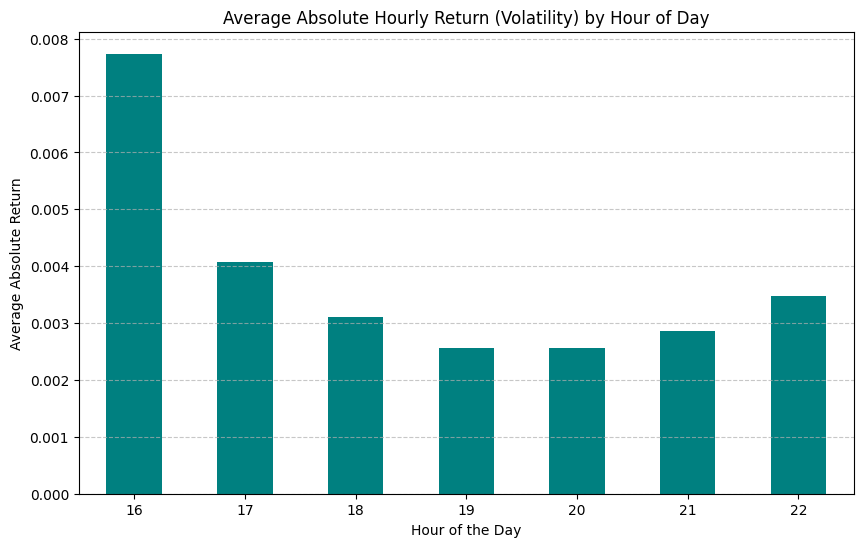

In [42]:
# Add a 'hour' column to group by
df_hourly['hour'] = df_hourly.index.hour

# Calculate the average absolute return for each hour of the day
hourly_volatility = df_hourly.groupby('hour')['returns'].apply(lambda x: np.abs(x).mean())

# Plotting
plt.figure(figsize=(10, 6))
hourly_volatility.plot(kind='bar', color='teal')
plt.title('Average Absolute Hourly Return (Volatility) by Hour of Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Absolute Return')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from ..scripts.utils.model_data_prep import prepare_data_for_modeling

ImportError: attempted relative import with no known parent package

/var/folders/2b/3vsd0zyj0sgcvhs1yllb22bw0000gn/T/ipykernel_84393/2477000035.py:11: FutureWarning: 'BH' is deprecated and will be removed in a future version, please use 'bh' instead.
  hourly_rng = pd.date_range(start='2023-01-01', end='2023-03-31', freq='BH') # Business Hours


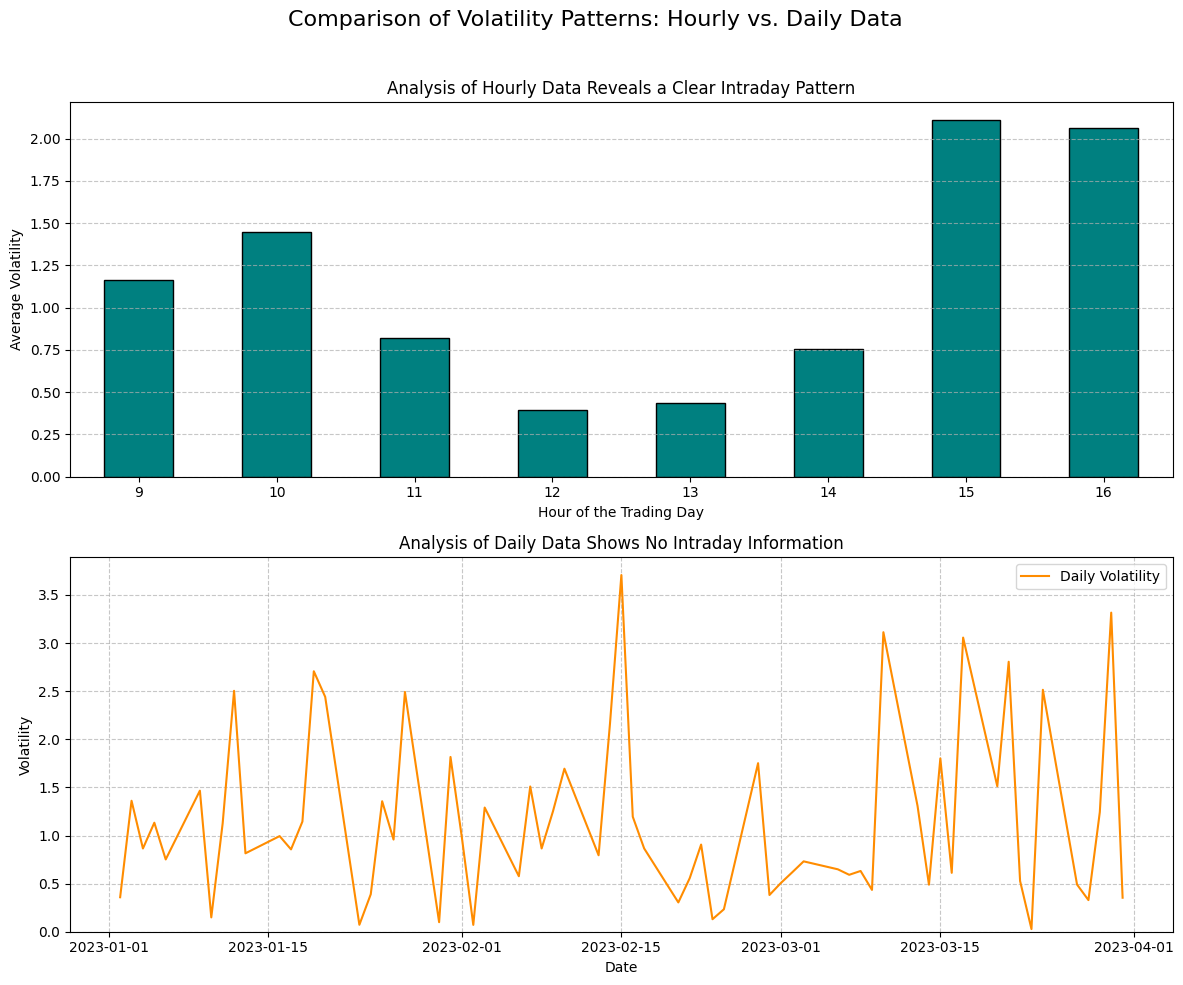

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Data ---
# Let's assume you have df_hourly and df_daily DataFrames
# For demonstration, let's create some sample data
# In your actual code, you will load your own data here.
np.random.seed(42)
# Hourly data
hourly_rng = pd.date_range(start='2023-01-01', end='2023-03-31', freq='BH') # Business Hours
hourly_data = np.random.randn(len(hourly_rng))
# Manually create the U-shape for demonstration
for i, idx in enumerate(hourly_rng):
    if idx.hour in [9, 10]: hourly_data[i] *= 2.0 # High vol at open
    if idx.hour in [15, 16]: hourly_data[i] *= 2.5 # Higher vol at close
    if idx.hour in [12, 13]: hourly_data[i] *= 0.5 # Low vol at midday
df_hourly = pd.DataFrame(hourly_data, index=hourly_rng, columns=['returns'])

# Daily data
daily_rng = pd.date_range(start='2023-01-01', end='2023-03-31', freq='B') # Business Days
daily_data = np.random.randn(len(daily_rng)) * 1.5
df_daily = pd.DataFrame(daily_data, index=daily_rng, columns=['returns'])


# --- 2. Process Hourly Data to Reveal Intraday Pattern ---
# We will use absolute returns as a proxy for volatility
df_hourly['volatility'] = df_hourly['returns'].abs()

# Add a 'hour' column to group by
df_hourly['hour'] = df_hourly.index.hour

# Calculate the average volatility for each hour of the day
intraday_vol_pattern = df_hourly.groupby('hour')['volatility'].mean()


# --- 3. Process Daily Data for Comparison ---
# Use absolute daily returns as the volatility proxy
df_daily['volatility'] = df_daily['returns'].abs()


# --- 4. Create the Comparison Plots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]})
fig.suptitle('Comparison of Volatility Patterns: Hourly vs. Daily Data', fontsize=16)

# Plot 1: The Intraday Volatility Pattern (Hourly Data)
intraday_vol_pattern.plot(kind='bar', ax=ax1, color='teal', edgecolor='black')
ax1.set_title('Analysis of Hourly Data Reveals a Clear Intraday Pattern', fontsize=12)
ax1.set_xlabel('Hour of the Trading Day')
ax1.set_ylabel('Average Volatility')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Volatility Over Time (Daily Data)
ax2.plot(df_daily.index, df_daily['volatility'], color='darkorange', label='Daily Volatility')
ax2.set_title('Analysis of Daily Data Shows No Intraday Information', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()
ax2.set_ylim(bottom=0) # Volatility cannot be negative

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/var/folders/2b/3vsd0zyj0sgcvhs1yllb22bw0000gn/T/ipykernel_84393/742973463.py:7: FutureWarning: 'BH' is deprecated and will be removed in a future version, please use 'bh' instead.
  hourly_rng = pd.date_range(start='2023-01-01', end='2023-03-31', freq='BH')


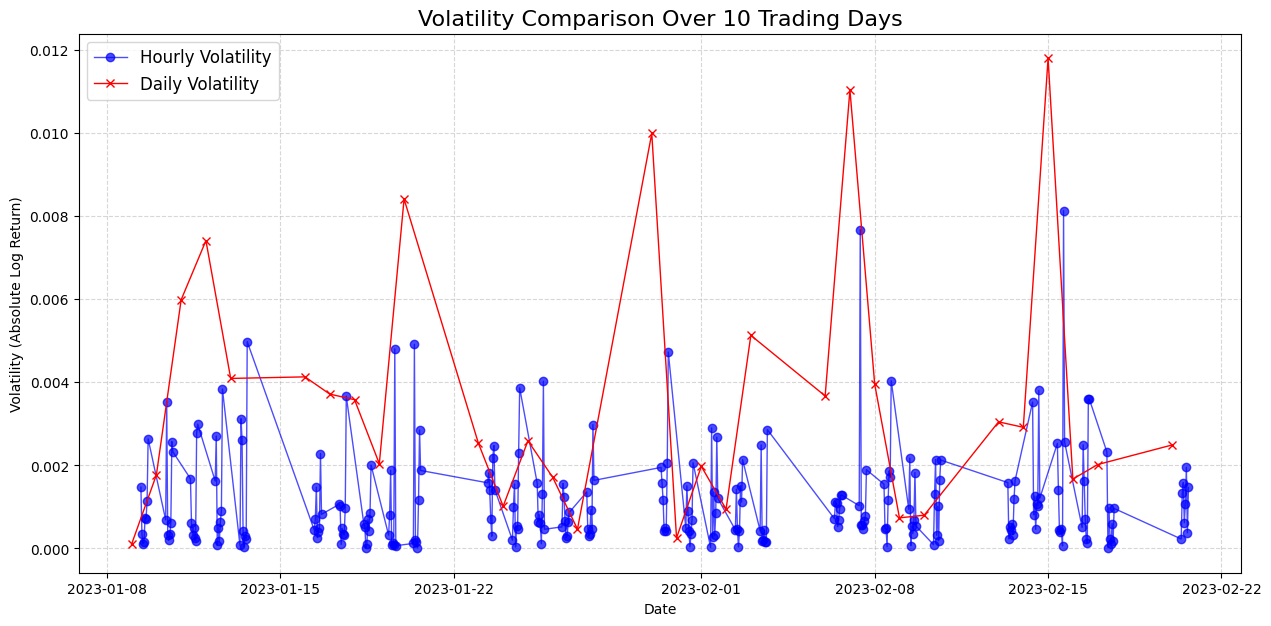

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Data (Using the corrected setup) ---
np.random.seed(42)
hourly_rng = pd.date_range(start='2023-01-01', end='2023-03-31', freq='BH')
sample_returns = np.random.randn(len(hourly_rng)) / 1000
for i, idx in enumerate(hourly_rng):
    if idx.hour in [9, 10]: sample_returns[i] *= 2.0
    if idx.hour in [15, 16]: sample_returns[i] *= 2.5
    if idx.hour in [12, 13]: sample_returns[i] *= 0.5

df_hourly = pd.DataFrame(index=hourly_rng)
df_hourly['price'] = 100 * (1 + sample_returns).cumprod()
df_hourly['returns'] = np.log(df_hourly['price']).diff()
df_hourly.dropna(inplace=True)

daily_close = df_hourly['price'].resample('D').last()
daily_open = df_hourly['price'].resample('D').first()
df_daily = pd.DataFrame({'open': daily_open, 'close': daily_close})
df_daily.dropna(inplace=True)
df_daily['returns'] = np.log(df_daily['close']) - np.log(df_daily['open'])

df_hourly['volatility'] = df_hourly['returns'].abs()
df_daily['volatility'] = df_daily['returns'].abs()

# --- 2. Select a Date Range for Plotting ---
start_date = '2023-01-09'
end_date = '2023-02-20' # Approx. 10 business days
hourly_subset = df_hourly.loc[start_date:end_date]
daily_subset = df_daily.loc[start_date:end_date]

# --- 3. Generate the Multi-Day Comparison Plot ---
plt.figure(figsize=(15, 7))

# Plot the high-frequency hourly volatility
plt.plot(hourly_subset.index, hourly_subset['volatility'], 
         label='Hourly Volatility', color='blue', alpha=0.7, linewidth=1.0, marker='o')

# Plot the daily volatility as a step function
plt.plot(daily_subset.index, daily_subset['volatility'], 
         label='Daily Volatility', color='red', linewidth=1.0, marker='x')

plt.title('Volatility Comparison Over 10 Trading Days', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volatility (Absolute Log Return)')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [53]:
# Group hourly data by date and find the max volatility for each day
peak_hourly_vol = df_hourly.loc[start_date:end_date].groupby(df_hourly.loc[start_date:end_date].index.date)['volatility'].max()

# Merge with the daily volatility for that same day
comparison_df = pd.DataFrame({'peak_hourly': peak_hourly_vol, 'daily': daily_subset['volatility']})
comparison_df['ratio'] = comparison_df['peak_hourly'] / comparison_df['daily']

# Calculate the average ratio
average_peak_ratio = comparison_df['ratio'].mean()

print(f"On average, the peak hourly volatility is {average_peak_ratio:.2f} times the daily volatility.")

On average, the peak hourly volatility is 2.44 times the daily volatility.


In [54]:
comparison_df

,peak_hourly,daily,ratio
2023-01-09,0.002639,0.000104,25.407179
2023-01-10,0.003532,0.001772,1.993620
2023-01-11,0.002995,0.005990,0.500024
2023-01-12,0.003838,0.007415,0.517582
2023-01-13,0.004981,0.004095,1.216325
...,...,...,...
2023-02-14 00:00:00,NaN,0.002918,NaN
2023-02-15 00:00:00,NaN,0.011809,NaN
2023-02-16 00:00:00,NaN,0.001672,NaN
2023-02-17 00:00:00,NaN,0.002021,NaN
